# Regularización para regresión y clasificación

## Regresión regularizada
Para ilustrar la regularización usando Ridge y Lasso, vamos a ajustar estos algoritmos a los datos del fichero `datos_regularizacion.csv` disponible en el aula virtual.

Cargad los datos en un dataframe llamado `datos`.


In [1]:
# Completar aquí
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os import path
import sklearn

DATA_DIRECTORY: path = path.abspath(path.join('..','data'))
file_path: path = path.join(DATA_DIRECTORY,"datos_regularizacion.csv")

datos = pd.read_csv(
    file_path,
    sep=','
)
# --------------------
datos

,x,y
0,-0.031161,1.532027
1,0.032386,0.758267
2,0.122271,1.048393
3,0.230400,1.066580
4,0.242299,1.373395
5,0.318407,-1.144595
6,0.367820,-1.241243
7,0.428989,-1.652124
8,0.474160,-1.085733
9,0.538686,0.077627


Llevad a cabo la representación gráfica del conjunto

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

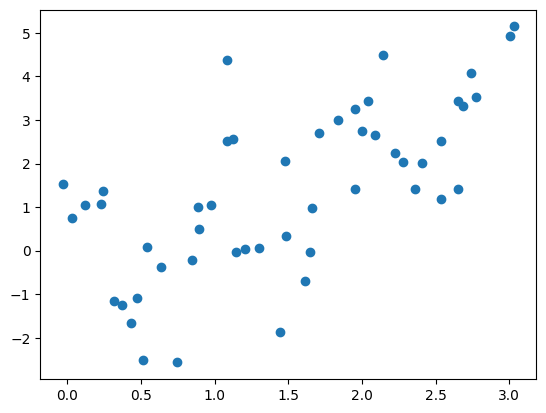

In [2]:
# Completar aquí
fig, ax = plt.subplots()
ax.scatter(datos["x"],datos["y"])
plt.plot
# --------------------


Ajustad una regresión lineal usando términos polinomiales de hasta grado 10. Después de incluir las características correspondientes a los términos de grado 10, llevad a cabo la estanderización de las características. 
Representad la curva ajustada en la gráfica anterior.

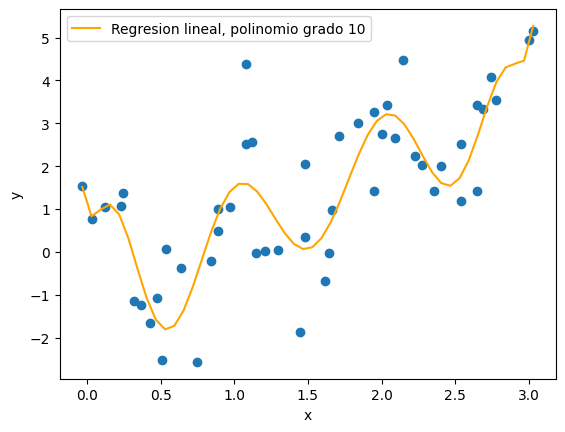

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

X = datos["x"].values.reshape(-1, 1)
y = datos["y"].values

linealProc = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

linealProc.fit(X, y)

X_range = np.linspace(X.min(), X.max()).reshape(-1, 1)
y_pred = linealProc.predict(X_range)

plt.scatter(X, y)
plt.plot(X_range, y_pred, label='Regresion lineal, polinomio grado 10', color='orange')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## Ajuste de una Ridge regression con `alpha=1`
Usando la clase `Ridge` del submódulo `linear_model`, aplicad a los datos una regresión ridge con `alpha=1` usando, al igual que en el apartado anterior, términos polinomiales de grado 10.


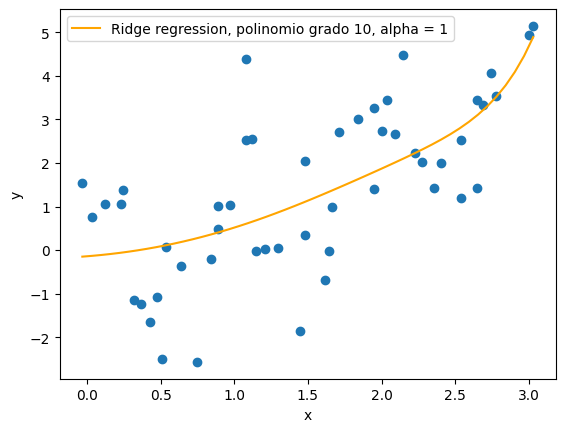

In [4]:
# Completar aquí
from sklearn.linear_model import Ridge

ridgeProc = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', Ridge(alpha=1))
])

ridgeProc.fit(X,y)
X_range = np.linspace(X.min(), X.max()).reshape(-1, 1)
y_pred = ridgeProc.predict(X_range)

plt.scatter(X, y)
plt.plot(X_range, y_pred, label='Ridge regression, polinomio grado 10, alpha = 1', color='orange')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
# --------------------


## Variamos `alpha` 
Representad los ajustes correspondientes a `alpha=0`, `alpha=0.00001`, `alpha=1` en la misma gráfica.
> Consejo: podéis usar un bucle sobre los valores de `alpha`, usando el método `set_params` que se puede aplicar a un estimador para cambiar algunos de sus parámetros (en este caso `alpha`)

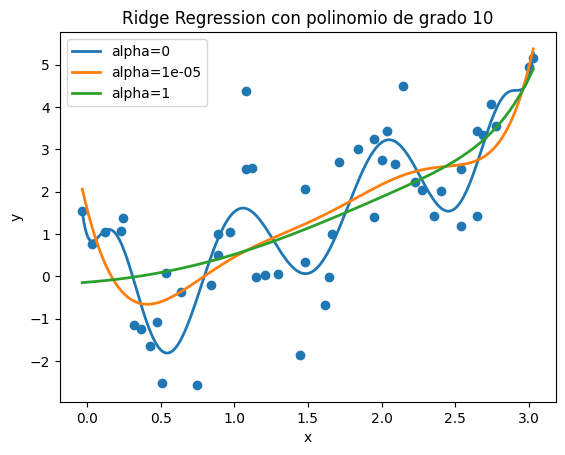

In [5]:
alphas = [0, 0.00001, 1]

plt.figure()

for i in alphas:
    ridgeProc = Pipeline([
        ('poly', PolynomialFeatures(degree=10, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=i))
    ])
    ridgeProc.fit(X, y)
    
    X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_pred = ridgeProc.predict(X_range)
    plt.plot(X_range, y_pred, label=f'alpha={i}', linewidth=2)

plt.scatter(X, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ridge Regression con polinomio de grado 10")
plt.legend()
plt.show()


# Clasificación regularizada: ejemplo con el conjunto MNIST
MNIST es un conjunto de datos muy clásico en machine learning que consiste en imágenes de dígitos escritos a mano en sobres. Las imágenes tienen una resolución de 28 por 28 píxeles, por lo que cada imagen tiene 784 características, cada característica corresponde a la intensidad de gris del pixel correspondiente, va desde 0 (blanco) a 255 (negro).

MNIST está disponible para descargar desde `sklearn`, pero vamos a cargar una versión reducida con 10000 imágenes, el fichero se llama `mnist_784.10000.csv` y está disponible en el aula virtual. Usad el parámetro `dtype` en `read_csv` para especificar que la columna `y` es de tipo `str`.

In [6]:
# Completar aquí: cargar los datos en un conjunto mnist
file_path: path = path.join(DATA_DIRECTORY,"mnist_784_10000.csv")

mnist = pd.read_csv(
    file_path,
    sep=','
)

# --------------------
mnist

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,y
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
9996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
9997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
9998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


Crear la `Series` `y` el `DataFrame` `X` 

In [7]:
# Completar aquí
import pandas as pd

X = mnist.drop(columns=['y'])
y = mnist['y']
# --------------------
print(f'Tamaño de X: {X.shape}, tamaño de y {y.shape}')

Tamaño de X: (10000, 784), tamaño de y (10000,)


Si queréis trabajar con el conjunto completo, se puede descargar directamente desde `sklearn`, tened en cuenta que los tiempos de ejecución son más largos.

In [8]:
# Si queréis trabajar con el conjunto completo:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
# el resultado es un diccionario, dos claves importantes son data y target
X, y = mnist['data'], mnist['target']
print(f'Tamaño de X: {X.shape}, tamaño de y {y.shape}')

Tamaño de X: (70000, 784), tamaño de y (70000,)


Podemos visualizar una de las imágenes:

Etiqueta: 8


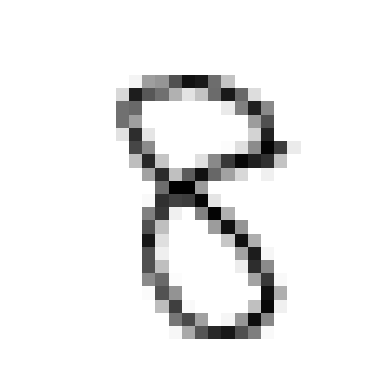

In [9]:
# nada que completar
from matplotlib import cm
fig, ax = plt.subplots()
imagen = X.iloc[3600,:].values.reshape(28, 28)
ax.imshow(
    imagen,
    cmap=cm.binary,
    interpolation='nearest'
)
ax.axis('off');
print(f'Etiqueta: {y.iloc[3600]}')

Representamos 10 imágenes escogidas al azar de cada etiqueta:

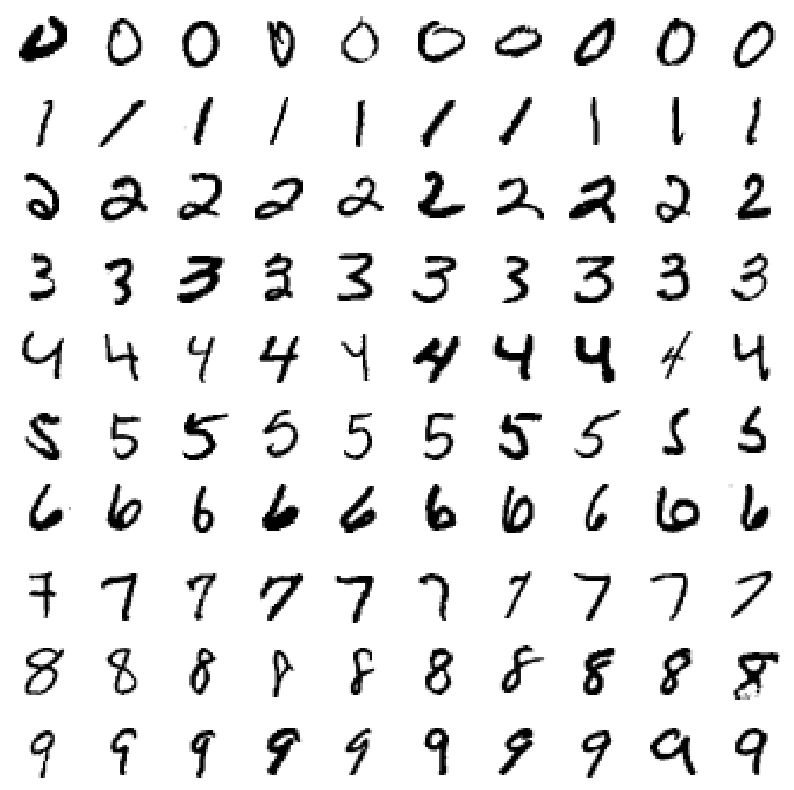

In [10]:
# Nada que completar
from numpy.random import default_rng
rng = default_rng(314)
fig, axes= plt.subplots(10, 10, figsize=(10,10))
for i in range(10):
    indexes = rng.choice(X[y==str(i)].index, replace=False,size=10)
    for j in range(10):
        imagen = X.loc[indexes[j],:].values.reshape(28, 28)
        axes[i, j].imshow(
            imagen,
            cmap=cm.binary,
            interpolation='nearest'
        )
        axes[i , j].axis('off');

## Separación conjunto de aprendizaje, conjunto de test
Lo primero que vamos a hacer es apartar un subconjunto de test.  Vamos a usar para ello `StratifiedShuffleSplit` del submódulo `model_selection`, que hace una separación (split) aleatoria, pero de manera que las dos partes generadas contengan proporciones parecidas de los valores de `y`. 

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit
# Empezamos por crear el objeto que realizará el split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=314)
for train_index, test_index in split.split(X, y):
    X_train, y_train = X.loc[train_index].values, y.loc[train_index].values
    X_test, y_test = X.loc[test_index].values, y.loc[test_index].values

Comprobad que se ha respetado la proporción de las etiquetas tanto en el conjunto train como en el conjunto test.

In [12]:
# Completar aquí
print(round(pd.Series(y_train).value_counts(normalize= True),1))
print(round(pd.Series(y_test).value_counts(normalize= True),1))
# --------------------


1    0.1
7    0.1
3    0.1
2    0.1
9    0.1
0    0.1
6    0.1
8    0.1
4    0.1
5    0.1
Name: proportion, dtype: float64
1    0.1
7    0.1
3    0.1
2    0.1
9    0.1
0    0.1
6    0.1
4    0.1
8    0.1
5    0.1
Name: proportion, dtype: float64


## Aplicación de la regresión logística con penalización l2
> No se trata de un problema de clasificación binario sino multiclases (10). El algoritmo `LogisticRegression` aplica automáticamente la estrategia de "One Versus all"

Siguiendo lo realizado en la práctica anterior, realizad sobre el conjunto de aprendizaje la predicción con penalización l2, usando el defecto de `C=1`, a través de validación cruzada. Antes de aplicar la regresión logística, estanderizad las características.
Guardad el resultado de las predicciones en `y_train_pred`.

> NOTA: para evitar un warning sobre convergencia, probad a aumentar el número 
máximo de iteraciones en `LogisticRegression` a través del argumento `max_iter`.

In [13]:
# Completar aquí
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

penalty:Pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', LogisticRegression(penalty='l2', max_iter=10000))
    ])
y_train_pred = cross_val_predict(penalty, X_train, y_train, cv=5)
# --------------------
y_train_pred[:15]

array(['6', '8', '4', '3', '2', '0', '3', '1', '0', '9', '5', '5', '0',
       '1', '7'], dtype=object)

Construid la matriz de confusión y asignadla a un objeto llamado `matriz_confusion`.

In [14]:
# Completar aquí
from sklearn.metrics import confusion_matrix

matriz_confusion = confusion_matrix(y_train, y_train_pred)
# --------------------
matriz_confusion

array([[5287,    1,   27,   16,   11,   57,   57,   18,   37,   11],
       [   1, 6118,   33,   20,    8,   21,    8,   22,   61,   10],
       [  47,   75, 4966,  110,   67,   36,   80,   76,  120,   15],
       [  28,   25,  157, 5050,   14,  189,   17,   58,  115,   60],
       [  21,   29,   44,   14, 5001,   17,   61,   42,   40,  190],
       [  52,   31,   45,  166,   61, 4356,  103,   21,  157,   58],
       [  45,   19,   70,    5,   51,   82, 5185,    7,   35,    2],
       [  13,   37,   73,   33,   57,   13,    3, 5399,   18,  188],
       [  41,  121,   81,  154,   24,  153,   48,   20, 4741,   77],
       [  29,   26,   11,   70,  156,   42,    3,  183,   43, 5004]])

Obtened la tasa de acierto del algoritmo. Para ello, podeís usar `numpy.trace` para obtener la traza de una matriz y por otra parte, compararlo con el resultado del método `accuracy_score` del súbmodulo `metrics`.

In [15]:
# Completar aquí
from sklearn.metrics import accuracy_score

t = np.trace(matriz_confusion) / X_train.shape[0]
a = accuracy_score(y_train, y_train_pred)
print(f'La tasa de acierto calculada a partir de la traza es {t}')
print(f'La misma tasa calculada usando el método accuracy_score es {a}')


La tasa de acierto calculada a partir de la traza es 0.912625
La misma tasa calculada usando el método accuracy_score es 0.912625


Vamos a calcular ahora la precisión. Al tratarse de un clasificación multiclases, lo que calculamos es la precisión para cada clase y hacemos el promedio de los 10 valores obtenidos.
Usando la matriz de confusión, calculad la precisión para cada clase (de 0 a 9). 
> Consejo: podéis usar el método `diagonal` aplicado a un array numpy para extraer los elementos diagonales y  `np.divide` para hacer la división de dos arrays, elemento a elemento

In [16]:
# Completar aquí
pre_col = np.divide(matriz_confusion.diagonal(), matriz_confusion.sum(axis=0))
# --------------------


Calculad la precision promedio sobre clases.


In [17]:
# Completar aquí

print(f'La precision promedio sobre las clases es {pre_col}')

La precision promedio sobre las clases es [0.95021567 0.94384449 0.90176139 0.8957077  0.91761468 0.87716472
 0.93171608 0.92353746 0.88336128 0.89118433]


Repetid estos cálculos para conseguir la sensibilidad promedio sobre clases

In [18]:
# Completar aquí
sen_col = np.divide(matriz_confusion.diagonal(), matriz_confusion.sum(axis = 1))
print(f'La sensibilidad promedio sobre las clases es {sen_col}')


La sensibilidad promedio sobre las clases es [0.95744296 0.97080292 0.88805436 0.88394889 0.91610185 0.86257426
 0.9425559  0.92543709 0.86831502 0.89886833]


En realidad, podríamos haber calculado directamente estos valores promedios usando `precision_score` y `recall_score` del submódulo `metrics`, con el parámetro `average="macro"`

In [19]:
# Completar aquí
from sklearn.metrics import precision_score, recall_score
prec_punct = precision_score(y_true = y_train, y_pred=y_train_pred,average='macro')
recall_punct = recall_score(y_true=y_train,y_pred=y_train_pred,average='macro')

print(f'Usando precision_score, la precisión promedio sobre clases es {prec_punct}')
print(f'Usando recall_score, la precisión promedio sobre clases es {recall_punct}')
# --------------------


Usando precision_score, la precisión promedio sobre clases es 0.9116107809741761
Usando recall_score, la precisión promedio sobre clases es 0.9114101576000371


Calculad la precisión y la sensibilidad promedio que obtenemos aplicando sobre el conjunto de test el modelo entrenado con el conjunto de aprendizaje.

In [20]:
# Completar aquí
penalty.fit(X_train, y_train)
# --------------------


Pipeline(steps=[('scaler', StandardScaler()),
                ('reg', LogisticRegression(max_iter=10000))])

In [21]:
y_pred = penalty.predict(X_test)

prec_punct = precision_score(y_true = y_test,y_pred= y_pred, average='macro')
prec_punct = recall_score(y_true = y_test,y_pred= y_pred, average='macro')

print(f'La precisión promedio sobre clases es{prec_punct}')
print(f'La sensibilidad promedio sobre clases es {recall_punct}')

La precisión promedio sobre clases es0.9135295855250073
La sensibilidad promedio sobre clases es 0.9114101576000371


## Búsqueda del mejor valor de `C` para la regresión logística regularizada.
Usad `GridSearchCV` para decidir qué valor de `C` fijar entre las siguientes posibilidades:
0.005, 0.01, 0.05, 0.1, 1.
> Recordad que para el problema de clasificación, el parámetro `scoring` debe tomar el valor 'accuracy'.

In [22]:
# Completar aquí
from sklearn.model_selection import GridSearchCV
gridSearch: GridSearchCV = GridSearchCV(
    estimator=penalty,
    param_grid={
        'reg__C': [0.00005, 0.01, 0.05, 0.1, 1]
    },
    cv=5,
    scoring='accuracy'
)

gridSearch.fit(X_train, y_train)
# --------------------


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('reg',
                                        LogisticRegression(max_iter=10000))]),
             param_grid={'reg__C': [5e-05, 0.01, 0.05, 0.1, 1]},
             scoring='accuracy')

Cuál es el valor de `C` que corresponde al mejor modelo? Corresponde a más o menos regularización que la opción por defecto de `LogisticRegression`?

Calculad, para el mejor modelo, la precisión promedio y la sensibilidad promedio sobre las clases, usando para empezar el conjunto de aprendizaje y a continuación el conjunto de test


In [23]:
# Completar aquí
gridSearch.best_estimator_.fit(X_train, y_train)
y_pred = gridSearch.best_estimator_.predict(X_train)

puntuacion_precision = precision_score(y_true = y_train, y_pred = y_pred, average = 'macro')
puntuacion_recall = recall_score(y_true = y_train, y_pred = y_pred, average = 'macro')
print('Para el conjunto de aprendizaje, usando el mejor modelo:')
print('')
print(f'Usando precision_score, la precisión promedio sobre clases es {puntuacion_precision:.5f}')
print(f'Usando recall_score, la sensibilidad promedio sobre clases es {puntuacion_recall:.5f}')

y_pred = gridSearch.best_estimator_.predict(X_test)

puntuacion_precision = precision_score(y_true = y_test, y_pred = y_pred, average = 'macro')
puntuacion_recall = recall_score(y_true = y_test, y_pred = y_pred, average = 'macro')

# --------------------
print('---------------------------------------------------------')
print('Para el conjunto de test, usando el mejor modelo:')
print('')
print(f'Usando precision_score, la precisión promedio sobre clases es {puntuacion_precision:.5f}')
print(f'Usando recall_score, la sensibilidad promedio sobre clases es {puntuacion_recall:.5f}')
print('---------------------------------------------------------')
# --------------------



Para el conjunto de aprendizaje, usando el mejor modelo:

Usando precision_score, la precisión promedio sobre clases es 0.93584
Usando recall_score, la sensibilidad promedio sobre clases es 0.93568
---------------------------------------------------------
Para el conjunto de test, usando el mejor modelo:

Usando precision_score, la precisión promedio sobre clases es 0.92320
Usando recall_score, la sensibilidad promedio sobre clases es 0.92299
---------------------------------------------------------
